# DSA 8301 — Kenya Housing Survey 2023/24
## Data Understanding · Cleaning · Feature Engineering
### Housing Financial Vulnerability Score (HFVS)

**Student:** Sephine Valerie Jerono | **No:** 222331  
**Supervisor:** Dr. John Olukuru  
**Institution:** Strathmore Institute of Mathematical Sciences (iLabAfrica)  
**Dataset:** KHS 2023/24 — KNBS · 21,347 households · 47 counties  

---

### Notebook Architecture

| Section | Purpose |
|---|---|
| §0 | Environment setup & paths |
| §1 | Data loading & structural audit |
| §2 | Missingness mapping & triage |
| §3 | Targeted cleaning (codes → semantics) |
| §4 | Feature engineering (three HFVS pillars) |
| §5 | Dimensionality reduction & final dataset assembly |
| §6 | Univariate & bivariate profiling |
| §7 | Export |

---

## §0 — Environment

In [1]:
# ── 0.1  Mount Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# ── 0.2  Core imports ────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import skew

warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 120)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F6', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.titlesize': 13,
    'axes.titleweight': '600', 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
sns.set_style('whitegrid')

TEAL  = '#00695C'; RED  = '#B71C1C'; AMBER = '#E65100'
BLUE  = '#1565C0'; GRAY = '#546E7A'; GREEN = '#2E7D32'

print('All imports loaded.')

All imports loaded.


In [3]:
# ── 0.3  Paths ───────────────────────────────────────────────────────────
DRIVE = Path('/content/drive/MyDrive/KHS_Dissertation')
PQ    = DRIVE / 'data' / 'parquet'
FIGS  = DRIVE / 'outputs' / 'figures' / 'dsa8301'
TABS  = DRIVE / 'outputs' / 'tables'  / 'dsa8301'
for p in [FIGS, TABS]: p.mkdir(parents=True, exist_ok=True)

MASTER_PATH = PQ / 'master_frame.parquet'
print(f'Paths configured. master_frame.parquet exists: {MASTER_PATH.exists()}')

Paths configured. master_frame.parquet exists: True


In [4]:
# ── 0.4  Load master frame ───────────────────────────────────────────────
if not MASTER_PATH.exists():
    alt = PQ / 'master_frame_clean.parquet'
    if alt.exists():
        MASTER_PATH = alt
    else:
        raise FileNotFoundError(
            'master_frame.parquet not found. Re-run the exploration notebook '
            'and save: master_clean.to_parquet(PQ / "master_frame.parquet")'
        )

master = pd.read_parquet(MASTER_PATH)
print(f'Loaded master frame: {master.shape[0]:,} rows × {master.shape[1]} columns')

print(f'\nColumn groups present (prefix scan):')
for prefix in ['hh_', 'county_', 'a0', 'b0', 'c0', 'c1', 'd0', 'd1', 'e0',
               'g0', 'h0', 'i0', 'j0', 'k0', 'l0', 'lp_', 'dw_', 'mort_',
               'fin_', 'loan_', 'wsvc_', 'nema_']:
    cols = [c for c in master.columns if c.startswith(prefix)]
    if cols:
        print(f'  {prefix:<10} {len(cols):>3} columns')

Loaded master frame: 21,347 rows × 443 columns

Column groups present (prefix scan):
  hh_          1 columns
  a0           2 columns
  c0          32 columns
  c1          39 columns
  d0           1 columns
  d1          10 columns
  e0          33 columns
  g0          35 columns
  h0           9 columns
  i0           1 columns
  j0          18 columns
  k0          13 columns
  l0          16 columns
  lp_          7 columns
  dw_         11 columns
  mort_        4 columns
  fin_         3 columns
  loan_        3 columns
  wsvc_        5 columns
  nema_        3 columns


---
## §1 — Structural Audit

In [5]:
# ── 1.1  Shape, dtypes, duplicate keys ───────────────────────────────────
print('=== SHAPE ===')
print(f'Rows: {master.shape[0]:,}  |  Columns: {master.shape[1]}')

print('\n=== DTYPE DISTRIBUTION ===')
print(master.dtypes.value_counts())

print('\n=== DUPLICATE KEYS ===')
dup_key = master.duplicated('interview__key').sum()
print(f'Duplicate interview__key rows: {dup_key}')

print('\n=== COUNTY COVERAGE ===')
n_counties = master['a01'].nunique()
print(f'Counties represented: {n_counties} / 47')

print('\n=== URBAN / RURAL SPLIT ===')
# a07_1: 1=Urban, 2=Rural  (KNBS coding)
ur = master['a07_1'].value_counts().rename({1: 'Urban', 2: 'Rural'})
print(ur.to_string())
print(f'Urban share: {(master["a07_1"]==1).mean()*100:.1f}%')

=== SHAPE ===
Rows: 21,347  |  Columns: 443

=== DTYPE DISTRIBUTION ===
float64    363
object      40
int8        22
float32     15
Int64        1
int32        1
int16        1
Name: count, dtype: int64

=== DUPLICATE KEYS ===
Duplicate interview__key rows: 0

=== COUNTY COVERAGE ===
Counties represented: 47 / 47

=== URBAN / RURAL SPLIT ===
a07_1
Urban    11900
Rural     9447
Urban share: 55.7%


In [6]:
# ── 1.2  Zero-variance columns (no analytical value) ─────────────────────
zero_var_cols = []
for col in master.select_dtypes('number').columns:
    if master[col].nunique(dropna=True) <= 1:
        zero_var_cols.append(col)

print(f'Zero/single-value columns to drop: {zero_var_cols}')

Zero/single-value columns to drop: ['k26__96', 'l02__8', 'tag', 'internet']


In [7]:
# ── 1.3  String / free-text columns (mostly empty, no modelling value) ───
str_cols = [c for c in master.columns
            if master[c].dtype == object or str(master[c].dtype) == 'str']

print(f'String columns ({len(str_cols)}): {str_cols}')
print('\nAll are SurveySolutions "other-specify" free-text or UUID identifiers.')
print('They carry no structured signal. Will be dropped.')

String columns (40): ['interview__key', 'interview__id', 'countycode', 'c01_1other', 'c01_2other', 'c02_1other', 'c02_2other', 'c03_other', 'c04other', 'c07_1', 'c09_other', 'c10_1', 'c11_other', 'c12_other', 'c13_other', 'e02_1', 'e03_1', 'e04_1', 'j06_2_other', 'j12_2other', 'j16_1', 'j19_1', 'j22_1', 'k04_1', 'k11_1', 'k12_1', 'k16_1', 'k22_1', 'k26_other', 'k30_1', 'k32_1', 'k33_other', 'k36_1', 'k39_other', 'l01_1a', 'l01_2a', 'l16_a', 'l19a', 'l22_1a', 'l27_a']

All are SurveySolutions "other-specify" free-text or UUID identifiers.
They carry no structured signal. Will be dropped.


---
## §2 — Missingness Mapping & Triage

The KHS master frame has **three distinct classes of missingness**:

| Class | Description | Strategy |
|---|---|---|
| **Skip-logic MCAR** | Module only asked of a sub-group (renters, owners, land-holders) | Impute with a sentinel or drop; never drop rows |
| **Item non-response MAR** | Question was applicable but HH refused / didn't know | Impute with median/mode within stratum |
| **Structural absence** | County-level supply vars: county not surveyed | Forward-fill by county code |


In [8]:
# ── 2.1  Full missingness profile ────────────────────────────────────────
miss_n   = master.isnull().sum()
miss_pct = miss_n / len(master) * 100

miss_df = (pd.DataFrame({'missing_n': miss_n, 'missing_pct': miss_pct})
           .query('missing_n > 0')
           .sort_values('missing_pct', ascending=False))

# Tier the columns
miss_df['tier'] = pd.cut(
    miss_df['missing_pct'],
    bins=[-1, 5, 30, 70, 101],
    labels=['LOW (<5%)', 'MODERATE (5–30%)', 'HIGH (30–70%)', 'EXTREME (>70%)']
)

print('=== MISSINGNESS TIER SUMMARY ===')
print(miss_df['tier'].value_counts().to_string())
print()
print('=== EXTREME MISSING COLUMNS (>70%) ===')
extreme = miss_df[miss_df['missing_pct'] > 70]
print(extreme[['missing_pct','tier']].to_string())

=== MISSINGNESS TIER SUMMARY ===
tier
EXTREME (>70%)      133
LOW (<5%)           122
HIGH (30–70%)       100
MODERATE (5–30%)     18

=== EXTREME MISSING COLUMNS (>70%) ===
                    missing_pct            tier
k10                     99.9344  EXTREME (>70%)
k32                     99.7096  EXTREME (>70%)
k27                     99.3676  EXTREME (>70%)
k24_1                   99.3676  EXTREME (>70%)
l24                     99.3020  EXTREME (>70%)
l27__6                  99.2130  EXTREME (>70%)
l27__4                  99.2130  EXTREME (>70%)
l27__3                  99.2130  EXTREME (>70%)
l27__5                  99.2130  EXTREME (>70%)
l27__96                 99.2130  EXTREME (>70%)
l27__1                  99.2130  EXTREME (>70%)
l27__2                  99.2130  EXTREME (>70%)
k36                     99.1896  EXTREME (>70%)
l12                     98.9038  EXTREME (>70%)
l09                     98.4073  EXTREME (>70%)
l11                     98.3136  EXTREME (>70%)
l10       

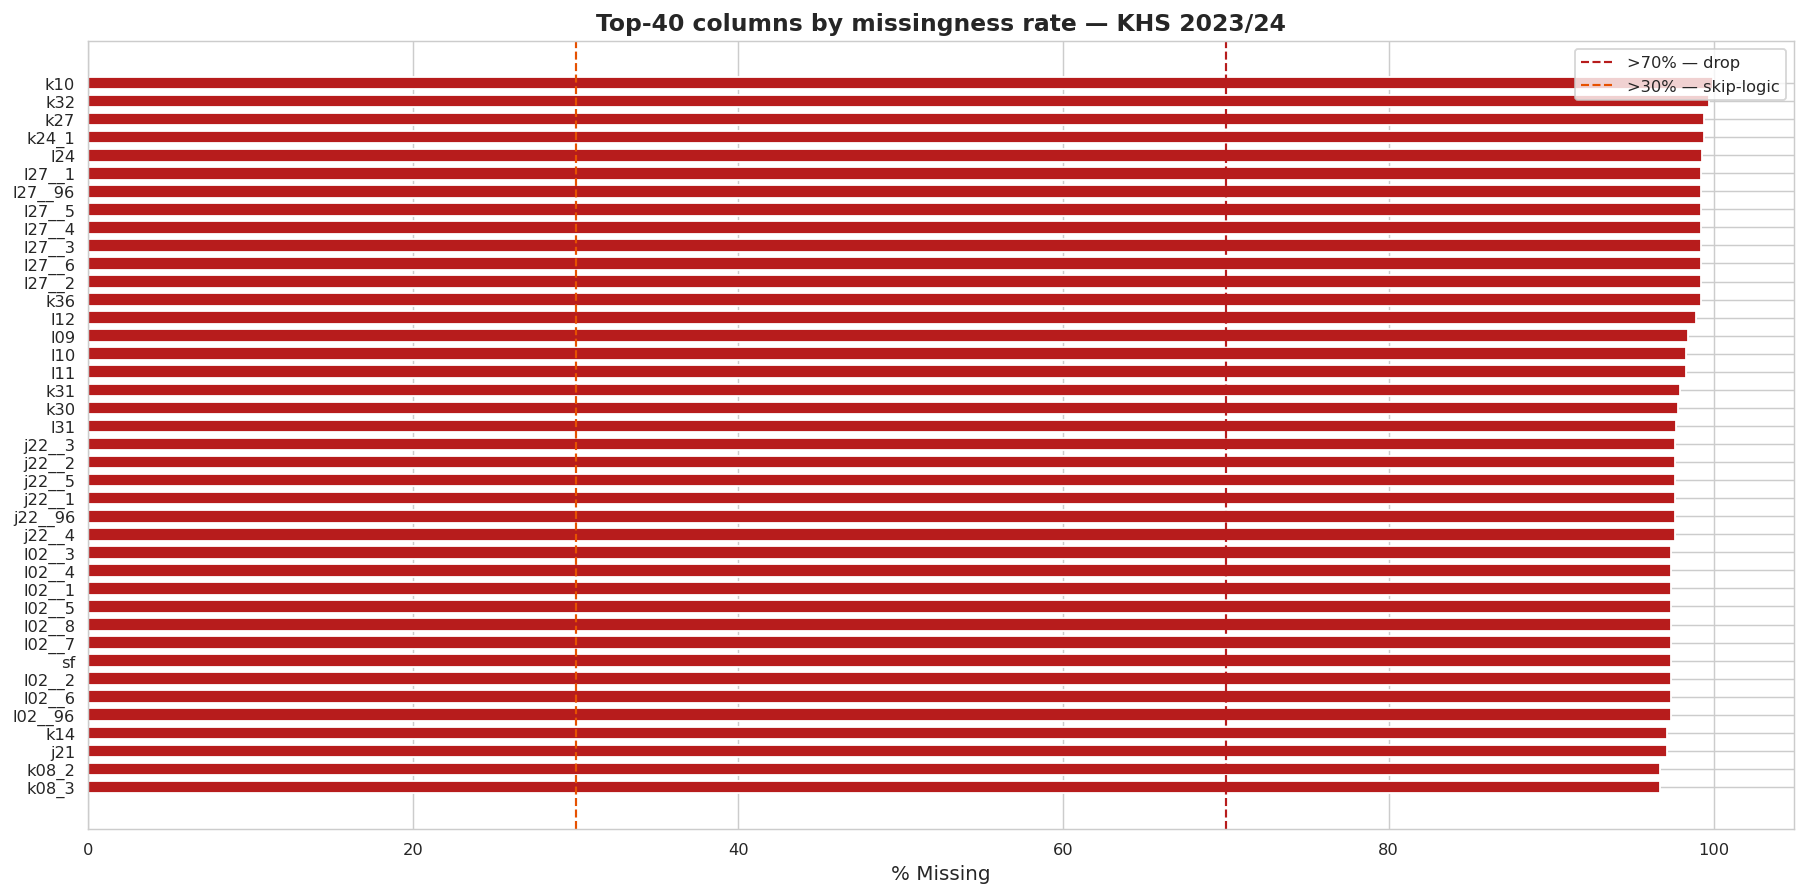

Figure saved.


In [9]:
# ── 2.2  Visualise missingness heatmap (top-40 affected columns) ─────────
top40_miss = miss_df.head(40).index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))
miss_pct_plot = miss_pct[top40_miss].sort_values(ascending=True)
colors = [RED if v > 70 else AMBER if v > 30 else TEAL for v in miss_pct_plot]
ax.barh(miss_pct_plot.index, miss_pct_plot.values, color=colors, height=0.7)
ax.axvline(70, color=RED,   ls='--', lw=1.2, label='>70% — drop')
ax.axvline(30, color=AMBER, ls='--', lw=1.2, label='>30% — skip-logic')
ax.set_xlabel('% Missing')
ax.set_title('Top-40 columns by missingness rate — KHS 2023/24')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'missingness_barh.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## §3 — Targeted Cleaning

Cleaning proceeds in strict order:
1. Drop noise (zero-variance, all-empty free-text, columns >85% missing with no HFVS relevance)
2. Fix survey codes (sentinels −1/98/99/999 → NaN)
3. Fix known inversions (Urban/Rural, year columns)
4. Recode categorical variables to interpretable ordinals/dummies
5. Impute residual missingness by class


In [10]:
# ── 3.1  Working copy ────────────────────────────────────────────────────
df = master.copy()
print(f'Working copy: {df.shape}')

Working copy: (21347, 443)


In [11]:
# ── 3.2  Drop zero-variance & free-text columns ──────────────────────────

# Zero-variance
drop_zero_var = zero_var_cols

# Free-text "other-specify" and UUID identifiers
# These are SurveySolutions artefacts — no structured signal
drop_freetext = str_cols  # all string columns

# Module K (renter-only) — 69%–99.9% missing and the informative signal
# is already captured in k05 (rent), k21 (arrears), k09 (lease type)
# which we keep and impute. The rest are noisy sub-questions.
k_deep = [c for c in df.columns
          if c.startswith('k') and c not in
          ['k05','k09','k21','k25','k13','k14','k07']]

# Module L sub-indicators mostly >97% missing (renovation detail, finance type)
l_deep = [c for c in df.columns
          if c.startswith('l') and c not in
          ['l07','l08','l13','l14','l15','l19','l21','l23','l24','l25','l26']]

# j16/j19/j22 relocation reason sub-items (>94% missing) — direction flags
# j06_2 move-reason sub-items (>30% missing duplicated by j06_1)
j_drop = ([c for c in df.columns if c.startswith('j16__')] +
          [c for c in df.columns if c.startswith('j19__')] +
          [c for c in df.columns if c.startswith('j22__')] +
          [c for c in df.columns if c.startswith('j06_2')])

# g06 aspirations (conditional only on those wanting improvement, 65–95% missing)
g06_drop = [c for c in df.columns if c.startswith('g06__')]

# l16 / l16b / l22_1 / l27 — renovation finance sub-items (>97% missing)
l_finance = ([c for c in df.columns if c.startswith('l16__')] +
             [c for c in df.columns if c.startswith('l16b__')] +
             [c for c in df.columns if c.startswith('l22_1__')] +
             [c for c in df.columns if c.startswith('l27__')] +
             [c for c in df.columns if c.startswith('l02__')])

# NEMA / supply-side county vars kept at county level — keep compact versions
# but drop granular sub-items with >80% missing
supply_drop = ['nema_eia_applications','nema_eia_approvals','nema_processing_days',
               'loan_avg_size','loan_outstanding','loan_n_providers',
               'fin_portfolio','fin_avg_tenure_months','fin_n_financiers',
               'mort_n_providers']

# Noise / survey admin columns
admin_drop = ['tag','serial','rnd','selectedage','a12','interview__id']

# c09 (source of water issue — sub-items) already captured by c01_1
c09_drop = [c for c in df.columns if c.startswith('c09__')]

# d18/d20 dwelling access granular items
d_drop = ([c for c in df.columns if c.startswith('d18__')] +
          [c for c in df.columns if c.startswith('d20__')])

# e02 waste type sub-items (captured by e01)
e02_drop = [c for c in df.columns if c.startswith('e02__')]

# c11_4 cooking sub-items (captured by c11)
c11_drop = [c for c in df.columns if c.startswith('c11_4__')]

all_drops = list(set(
    drop_zero_var + drop_freetext + k_deep + l_deep + j_drop +
    g06_drop + l_finance + supply_drop + admin_drop +
    c09_drop + d_drop + e02_drop + c11_drop
))

# Only drop what actually exists in df
all_drops = [c for c in all_drops if c in df.columns]
df.drop(columns=all_drops, inplace=True)

print(f'Dropped {len(all_drops)} columns  |  Remaining: {df.shape[1]}')

Dropped 254 columns  |  Remaining: 189


In [12]:
# ── 3.3  Replace SurveySolutions sentinel codes with NaN ─────────────────
# SurveySolutions uses -1=skipped, 98/998=don't know, 99/999=refused, 96=other
# We nullify -1 universally and the "don't know / refused" codes for numeric vars

SENTINEL_CODES = [-1, 98, 99, 998, 999]

num_cols = df.select_dtypes('number').columns.tolist()
replaced = 0
for col in num_cols:
    mask = df[col].isin(SENTINEL_CODES)
    replaced += mask.sum()
    df.loc[mask, col] = np.nan

print(f'Sentinel codes nullified: {replaced:,} cells across {len(num_cols)} numeric columns.')

Sentinel codes nullified: 10,419 cells across 189 numeric columns.


In [14]:
# 3.4c  j12_1 is survey year of occupancy — values < 100 are "duration" codes
# Values 1900–2024 are years; value==1 means <1 year; 99=DK
# We will handle this during feature engineering (yrs_in_dwelling)

if 'l28' in df.columns:
    df.loc[df['l28'] < 1900, 'l28'] = np.nan  # renovation year anomalies
    print(f'Renovation year (l28) after cleaning: n={df["l28"].notna().sum()}')
else:
    print('l28 (renovation year) not found in dataset — skipping.')

l28 (renovation year) not found in dataset — skipping.


In [15]:
print([c for c in df.columns if c.startswith('l')])

['l07', 'l08', 'l13', 'l14', 'l15', 'l19', 'l21', 'l23', 'l24', 'l25', 'l26']


In [16]:
# ── 3.4  Fix known inversions & anomalies ────────────────────────────────

# 3.4a  Urban/Rural binary: recode to 1=Urban, 0=Rural for clarity
# KNBS coding: a07_1==1 → Urban, a07_1==2 → Rural
df['is_urban'] = (df['a07_1'] == 1).astype('int8')
print('is_urban distribution:')
print(df['is_urban'].value_counts())

# 3.4b  Dwelling year built anomalies: l08<1920 or l08>2024 → NaN
# Note: l08=0 in SurveySolutions means not answered (tag rows with value=0)
bad_year_mask = (df['l08'] < 1920) | (df['l08'] > 2024)
print(f'\nAnomalous l08 (year built) values: {bad_year_mask.sum()}')
df.loc[bad_year_mask, 'l08'] = np.nan

# 3.4c  l28 (year last renovated) not present in this export.
# Using l21 (renovation done flag) as binary proxy instead.
if 'l21' in df.columns:
    print(f'Renovation flag (l21) distribution:\n{df["l21"].value_counts()}')
else:
    print('l21 (renovation flag) also absent — skipping renovation cleaning.')

# 3.4d  Floor area extremes: >p99 for residential is implausible
p99_area = df['dw_floor_area_m2'].quantile(0.99)
df.loc[df['dw_floor_area_m2'] > p99_area, 'dw_floor_area_m2'] = np.nan
print(f'\nFloor area p99 cap at {p99_area:.0f} m²')

# 3.4e  Rent extremes: k05 > p99 are likely data entry errors
p99_rent = df['k05'].quantile(0.99)
df.loc[df['k05'] > p99_rent, 'k05'] = np.nan
print(f'Rent p99 cap at {p99_rent:.0f} KES/month')

# 3.4f  Income sub-components: cap extreme outliers at p99 per component
g_cols = [c for c in df.columns if c.startswith('g01')]
for col in g_cols:
    p99 = df[col].quantile(0.99)
    df.loc[df[col] > p99, col] = np.nan
print(f'Income components (g01*) outliers capped at p99 — {len(g_cols)} cols.')

is_urban distribution:
is_urban
1    11900
0     9447
Name: count, dtype: int64

Anomalous l08 (year built) values: 0
Renovation flag (l21) distribution:
l21
0.0000    10892
1.0000     2269
Name: count, dtype: int64

Floor area p99 cap at 1200 m²
Rent p99 cap at 30000 KES/month
Income components (g01*) outliers capped at p99 — 11 cols.


In [17]:
# ── 3.5  County code — ensure integer and forward-fill ───────────────────
df['county_code'] = df['a01'].astype('Int64')
print('County codes missing:', df['county_code'].isna().sum())
print('Counties:', sorted(df['county_code'].dropna().unique().tolist()))

County codes missing: 0
Counties: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]


---
## §4 — Feature Engineering

The HFVS rests on **three pillars**. All engineered features map explicitly to one pillar:

| Pillar | Concept | Key raw inputs |
|---|---|---|
| **P1 — Financial Stress** | Rent burden, income fragility, expenditure gaps | g01*, g02_1, k05, c14_*, j09–j11 |
| **P2 — Physical Quality** | Structure, services, overcrowding, environment | dw_*, c01_1, c04, c10, c11, h01–h11, e05–e07 |
| **P3 — Tenure Security** | Ownership, title, dispute, mobility | j04_1, lp_*, k21, j13, d01 |


In [18]:
# ── 4.1  PILLAR 1: Financial Stress ──────────────────────────────────────

# --- 4.1a  Total household expenditure proxy ---
# g01a–k = food, clothing, education, health, transport, comms,
#           recreation, housing costs, energy, other, remittances
g_expenditure_cols = [f'g01{x}' for x in 'abcdefghijk']
g_available = [c for c in g_expenditure_cols if c in df.columns]
df['total_expenditure'] = df[g_available].sum(axis=1, min_count=6)  # need ≥6 components
print(f'total_expenditure: n={df["total_expenditure"].notna().sum():,}  mean={df["total_expenditure"].mean():.0f} KES')

# --- 4.1b  Housing cost burden ---
# For renters: housing_cost = k05 (monthly rent)
# For owners:  housing_cost = l15 (monthly mortgage) if available, else g01h (reported housing costs)
# Unified: use g01h as it covers all tenure types
df['housing_cost_kes'] = df['g01h'].fillna(df['k05'].fillna(df['l15']))
print(f'housing_cost_kes: n={df["housing_cost_kes"].notna().sum():,}  mean={df["housing_cost_kes"].mean():.0f} KES')

# --- 4.1c  Housing cost burden ratio ---
# WHO/UN-Habitat threshold: >30% of income = burdened
df['housing_burden_ratio'] = np.where(
    df['total_expenditure'] > 0,
    df['housing_cost_kes'] / df['total_expenditure'],
    np.nan
)
# Cap at 1.0 (some HHs spend >100% — measurement error or borrowing)
df['housing_burden_ratio'] = df['housing_burden_ratio'].clip(0, 1)

df['is_cost_burdened'] = (df['housing_burden_ratio'] > 0.30).astype('float')
print(f'\nhousing_burden_ratio: mean={df["housing_burden_ratio"].mean():.3f}')
print(f'is_cost_burdened (>30%): {df["is_cost_burdened"].mean()*100:.1f}% of households')

# --- 4.1d  Utility expenditure share ---
# c14_1=water, c14_2=electricity, c14_3=other energy
df['utility_expenditure'] = df[['c14_1','c14_2','c14_3']].sum(axis=1, min_count=1)
df['utility_burden_ratio'] = np.where(
    df['total_expenditure'] > 0,
    df['utility_expenditure'] / df['total_expenditure'],
    np.nan
).clip(0, 1)
print(f'\nutility_burden_ratio: mean={df["utility_burden_ratio"].mean():.3f}')

# --- 4.1e  Self-reported financial stress flags ---
# j09: could not pay rent/mortgage last 12 months
# j10: skipped meals due to inability to pay housing costs
# j11: took on debt to meet housing costs
stress_cols = ['j09', 'j10', 'j11']
df['financial_stress_count'] = df[stress_cols].sum(axis=1, min_count=1)
df['any_financial_stress']   = (df['financial_stress_count'] > 0).astype('float')
print(f'\nany_financial_stress: {df["any_financial_stress"].mean()*100:.1f}% of households')

# --- 4.1f  Rent arrears (renter-only) ---
# k21: 1=no arrears, 2=1-3 months, 3=>3 months
# Recode: 0=no arrears, 1=in arrears
df['in_rent_arrears'] = np.where(
    df['k21'].notna(), (df['k21'] > 1).astype('float'), np.nan
)
print(f'in_rent_arrears: {df["in_rent_arrears"].mean()*100:.1f}% of renters')

# --- 4.1g  Income proxies from asset ownership ---
# c13__1=radio, c13__2=phone, c13__3=TV, c13__4=computer,
# c13__5=motorcycle, c13__6=car, c13__7=fridge
asset_cols = [f'c13__{i}' for i in [1,2,3,4,5,6,7] if f'c13__{i}' in df.columns]
asset_weights = {'c13__1':1, 'c13__2':1, 'c13__3':2, 'c13__4':3,
                 'c13__5':2, 'c13__6':4, 'c13__7':2}
df['asset_score'] = sum(
    df[c].fillna(0) * asset_weights.get(c, 1)
    for c in asset_cols
)
print(f'\nasset_score: mean={df["asset_score"].mean():.2f}, max={df["asset_score"].max()}')

print('\n✓ Pillar 1 (Financial Stress) features created.')

total_expenditure: n=21,298  mean=26437 KES
housing_cost_kes: n=21,339  mean=5212 KES

housing_burden_ratio: mean=0.143
is_cost_burdened (>30%): 11.7% of households

utility_burden_ratio: mean=0.617

any_financial_stress: 51.8% of households
in_rent_arrears: 44.0% of renters

asset_score: mean=0.56, max=15.0

✓ Pillar 1 (Financial Stress) features created.


In [19]:
# ── 4.2  PILLAR 2: Physical Quality ──────────────────────────────────────

# --- 4.2a  Wall material quality score (1=high, 0=low) ---
# dw_wall_material codes (KNBS): 1=stone/brick, 2=block, 3=timber treated,
# 4=corrugated iron, 5=mud/wood, 6=mud/cement, 7=grass/thatch, 8=bamboo+, ...
wall_durable = {1, 2, 3, 6}   # stone, block, treated timber, mud/cement
wall_poor    = {5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}  # informal/temporary
df['wall_durable'] = df['dw_wall_material'].map(
    lambda x: 1 if x in wall_durable else (0 if x in wall_poor else np.nan)
)

# --- 4.2b  Roof material quality ---
# 1=iron sheet, 2=tile/slate, 3=concrete, 4=asbestos (legacy adequate),
# 5=grass/thatch, 6=tin, 7=bamboo/wood, 8+=informal
roof_durable = {1, 2, 3}       # iron sheet, tiles, concrete
roof_poor    = {5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15}
df['roof_durable'] = df['dw_roof_material'].map(
    lambda x: 1 if x in roof_durable else (0 if x in roof_poor else np.nan)
)

# --- 4.2c  Floor material quality ---
# 1=cement/concrete, 2=tiles, 3=earth/mud, 4=wood, 5=bamboo, 6+=informal
floor_durable = {1, 2, 4}    # cement, tiles, wood
floor_poor    = {3, 5, 6, 7, 8, 9}
df['floor_durable'] = df['dw_floor_material'].map(
    lambda x: 1 if x in floor_durable else (0 if x in floor_poor else np.nan)
)

# --- 4.2d  Composite structure quality score (0–3) ---
structure_cols = ['wall_durable', 'roof_durable', 'floor_durable']
df['structure_quality'] = df[structure_cols].sum(axis=1, min_count=2)
print(f'structure_quality (0-3): mean={df["structure_quality"].mean():.2f}')
print(df['structure_quality'].value_counts(dropna=False))

# --- 4.2e  Safe water access ---
# c01_1: 1=piped in dwelling, 2=piped yard, 3=piped public,
# 4=borehole, 5=protected spring, 6=protected well,
# 7=unprotected well, 8=unprotected spring, 9=rainwater,
# 10=river/stream, 11=vendor, 96=other
safe_water = {1, 2, 3, 4, 5, 6}   # JMP "improved" sources
df['safe_water'] = df['c01_1'].map(
    lambda x: 1 if x in safe_water else (0 if pd.notna(x) else np.nan)
)
print(f'\nsafe_water: {df["safe_water"].mean()*100:.1f}% have improved water')

# --- 4.2f  Improved sanitation ---
# c04: 1=flush sewer, 2=flush septic, 3=flush pit, 4=VIP,
# 5=improved pit, 6=traditional pit, 7=bucket/hanging, 8=none/open
improved_san = {1, 2, 3, 4, 5}  # JMP "improved" (excluding shared)
df['improved_sanitation'] = df['c04'].map(
    lambda x: 1 if x in improved_san else (0 if pd.notna(x) else np.nan)
)
print(f'improved_sanitation: {df["improved_sanitation"].mean()*100:.1f}% have improved sanitation')

# --- 4.2g  Clean energy for cooking ---
# c11: 9=charcoal, 7=firewood (dirty) | 11=LPG, 1=electricity, 4=biogas (clean)
clean_cooking = {1, 2, 4, 11, 12}  # electricity, solar, biogas, LPG, ethanol
df['clean_cooking'] = df['c11'].map(
    lambda x: 1 if x in clean_cooking else (0 if pd.notna(x) else np.nan)
)
print(f'clean_cooking: {df["clean_cooking"].mean()*100:.1f}% use clean fuel')

# --- 4.2h  Electricity access ---
# c10: 1=grid, 2=rural electrification, 4=solar — all constitute access
electricity = {1, 2, 3, 4}    # grid, rural-electrification, generator, solar
df['has_electricity'] = df['c10'].map(
    lambda x: 1 if x in electricity else (0 if pd.notna(x) else np.nan)
)
print(f'has_electricity: {df["has_electricity"].mean()*100:.1f}% have electricity')

# --- 4.2i  Overcrowding ---
# UN-Habitat standard: >2 persons per habitable room
# dw_n_rooms==1→single room, ==2→2+ rooms
df['persons_per_room'] = df['hh_size'] / df['dw_n_rooms'].replace(0, np.nan)
df['is_overcrowded'] = (df['persons_per_room'] > 2).astype('float')
print(f'\nis_overcrowded (>2 p/room): {df["is_overcrowded"].mean()*100:.1f}% of households')

# --- 4.2j  Environmental hazard exposure ---
# e05: flood frequency (1=very frequent, higher=less frequent based on pattern)
# e06: 0=no landslide risk, 1=some, 2=high
# e07: 0=no other hazard, 1=some, 2=high
# Recode e05: 1 = high flood risk (coded as 1 = frequent floods)
df['flood_risk'] = (df['e05'] == 1).astype('float')
df['landslide_risk'] = (df['e06'] > 0).astype('float')
df['env_hazard_any'] = ((df['flood_risk'] == 1) | (df['landslide_risk'] == 1)).astype('float')
print(f'\nflood_risk: {df["flood_risk"].mean()*100:.1f}%')
print(f'env_hazard_any: {df["env_hazard_any"].mean()*100:.1f}%')

# --- 4.2k  Perceived housing quality (h01–h11, 1=Good, 3=Poor) ---
# Invert so higher = better, then average
h_cols = [f'h{i:02d}' for i in range(1, 12)]
h_available = [c for c in h_cols if c in df.columns]
# Invert: 4 - rating so 3=Good, 1=Poor
h_inverted = df[h_available].apply(lambda x: 4 - x)
df['perception_quality_score'] = h_inverted.mean(axis=1)
print(f'\nperception_quality_score: mean={df["perception_quality_score"].mean():.2f} (1=Poor, 3=Good)')

# --- 4.2l  Dwelling age ---
# l08 = year built
df['dwelling_age_yrs'] = (2024 - df['l08']).clip(0, 100)
df['dwelling_age_yrs'] = df['dwelling_age_yrs'].where(df['l08'].notna(), np.nan)
print(f'\ndwelling_age_yrs: mean={df["dwelling_age_yrs"].mean():.1f} yrs')

# --- 4.2m  Housing problems composite ---
# g05__1=overcrowding, __2=poor water, __3=poor sanitation, __4=structural defects,
# __5=pests/vermin, __6=inadequate light, __7=inadequate ventilation,
# __8=high cost, __9=insecurity, __10=poor transport
g05_physical = [f'g05__{i}' for i in [1,2,3,4,5,6,7] if f'g05__{i}' in df.columns]
df['n_housing_problems'] = df[g05_physical].sum(axis=1, min_count=3)
print(f'n_housing_problems: mean={df["n_housing_problems"].mean():.2f}')

print('\n✓ Pillar 2 (Physical Quality) features created.')

structure_quality (0-3): mean=2.67
structure_quality
3.0000    16165
2.0000     2179
1.0000     1151
NaN        1091
0.0000      761
Name: count, dtype: int64

safe_water: 60.0% have improved water
improved_sanitation: 20.1% have improved sanitation
clean_cooking: 18.3% use clean fuel
has_electricity: 63.8% have electricity

is_overcrowded (>2 p/room): 56.5% of households

flood_risk: 44.2%
env_hazard_any: 55.5%

perception_quality_score: mean=1.80 (1=Poor, 3=Good)

dwelling_age_yrs: mean=4.0 yrs
n_housing_problems: mean=1.65

✓ Pillar 2 (Physical Quality) features created.


In [23]:
df.columns

Index(['a01', 'a07_1', 'c01_1', 'c01_2', 'c01_3', 'c01_4', 'c01_5', 'c02_1',
       'c02_2', 'c02_3',
       ...
       'persons_per_room', 'is_overcrowded', 'flood_risk', 'landslide_risk',
       'env_hazard_any', 'perception_quality_score', 'dwelling_age_yrs',
       'n_housing_problems', 'tenure_security_score', 'is_renter'],
      dtype='object', length=219)

In [27]:
# ── 4.3  PILLAR 3: Tenure Security ───────────────────────────────────────

# --- 4.3a  Tenure type ordinal ---
tenure_security_map = {
    2: 3,   # owner-occupied — fully secure
    5: 2,   # mortgaged — encumbered but legally secure
    6: 2,   # customary — community-recognised
    1: 1,   # rented — legally protected but precarious
    4: 1,   # employer provided — precarious
    3: 0,   # rent-free — no legal claim
    7: 0,   # squatter — fully insecure
}
df['tenure_security_score'] = df['d01'].map(tenure_security_map)
print('tenure_security_score (0=insecure, 3=secure):')
print(df['tenure_security_score'].value_counts().sort_index())

# --- 4.3b  Renter flag ---
df['is_renter'] = (df['j04_1'] == 1).astype('int8')
print(f'\nis_renter: {df["is_renter"].mean()*100:.1f}%')

# --- 4.3c  Title deed / land registration security ---
# i05 (title deed) and i08 (land dispute) from LAND_PARCELS were not merged
# into the main df — only i00 is present. Skipping has_title_deed and
# land_dispute; tenure security is captured via tenure_security_score.

# --- 4.3d  Tenure dissatisfaction ---
# j13: 0=not satisfied with tenure, 1=satisfied
df['tenure_satisfied'] = df['j13']
print(f'tenure_satisfied: {df["tenure_satisfied"].mean()*100:.1f}%')

# --- 4.3e  Years in dwelling (stability proxy) ---
def decode_years_in_dwelling(val):
    if pd.isna(val):
        return np.nan
    if val >= 1900:
        return max(0, 2024 - val)
    elif val <= 50:
        return val
    else:
        return np.nan

df['yrs_in_dwelling'] = df['j12_1'].apply(decode_years_in_dwelling).clip(0, 50)
print(f'\nyrs_in_dwelling: mean={df["yrs_in_dwelling"].mean():.1f} yrs, n={df["yrs_in_dwelling"].notna().sum():,}')

# --- 4.3f  Mortgage market access (county-level) ---
df['county_mort_ltv'] = df['mort_ltv_ratio']
df['county_mort_rate'] = df['mort_interest_rate']
print(f'\ncounty_mort_ltv: mean={df["county_mort_ltv"].mean():.1f}%  missing={df["county_mort_ltv"].isna().sum()}')

print('\n✓ Pillar 3 (Tenure Security) features created.')

tenure_security_score (0=insecure, 3=secure):
tenure_security_score
0      478
1    18310
2       11
3     2548
Name: count, dtype: int64

is_renter: 61.9%
tenure_satisfied: 50.7%

yrs_in_dwelling: mean=6.6 yrs, n=20,545

county_mort_ltv: mean=60.3%  missing=13577

✓ Pillar 3 (Tenure Security) features created.


In [28]:
print([c for c in df.columns if c.startswith('lp') or c.startswith('i0') or c.startswith('i1')])

['i00']


In [29]:
# ── 4.4  Household composition & demographic controls ────────────────────

# Female-headed household
# hhh_sex: 1=Male, 2=Female  → recode to binary
df['female_headed'] = (df['hhh_sex'] == 2).astype('float')
print(f'female_headed: {df["female_headed"].mean()*100:.1f}%')

# Dependency ratio: (children + elderly) / working_age
# Already computed, but ensure sensible range
df['dependency_ratio'] = df['dependency_ratio'].clip(0, 5)
print(f'dependency_ratio: mean={df["dependency_ratio"].mean():.2f}')

# Household size (log for modelling, heavy right-skew)
df['log_hh_size'] = np.log1p(df['hh_size'])

# Education level (household head maximum ISCED)
# max_edu_isced: 3=lower sec, 6=upper sec, 7=post-sec, 8=short tertiary,
#                9=bachelor, 10=master, 14=PhD, 16=none
# Recode to ordered tiers: 0=none/primary, 1=secondary, 2=tertiary
edu_tier_map = {
    16: 0,  # none
    3:  0,  # primary/lower-sec
    4:  0,
    5:  0,
    6:  1,  # upper secondary
    7:  1,  # post-secondary non-tertiary
    8:  2,  # short cycle tertiary
    9:  2,  # bachelor
    10: 2,  # master
    14: 2,  # doctoral
}
df['edu_tier'] = df['max_edu_isced'].map(edu_tier_map)
print(f'edu_tier distribution:\n{df["edu_tier"].value_counts().sort_index().to_string()}')

print('\n✓ Demographic controls created.')

female_headed: 31.9%
dependency_ratio: mean=0.76
edu_tier distribution:
edu_tier
0.0000    12386
1.0000     7113
2.0000     1809

✓ Demographic controls created.


In [30]:
# ── 4.5  County-level supply-side features ───────────────────────────────

# These are already merged at household level. Fill by county median where missing.
county_supply = [
    'cty_housing_stock', 'cty_housing_backlog', 'cty_planning_staff',
    'cty_has_housing_policy', 'cty_building_approval_system',
    'wsvc_water_connections', 'wsvc_sewer_connections',
    'wsvc_water_tariff', 'wsvc_service_quality', 'wsvc_n_providers',
    'mort_ltv_ratio', 'mort_avg_term_years',
]
county_supply = [c for c in county_supply if c in df.columns]

for col in county_supply:
    miss_before = df[col].isna().sum()
    county_median = df.groupby('county_code')[col].transform('median')
    df[col] = df[col].fillna(county_median)
    # If still missing (county had no data at all), use national median
    df[col] = df[col].fillna(df[col].median())
    miss_after = df[col].isna().sum()
    print(f'{col:<35}: {miss_before:>5} → {miss_after} missing')

# Derive housing supply gap ratio = backlog / stock
if 'cty_housing_stock' in df.columns and 'cty_housing_backlog' in df.columns:
    df['cty_housing_gap_ratio'] = (
        df['cty_housing_backlog'] /
        df['cty_housing_stock'].replace(0, np.nan)
    ).clip(0, 5)
    print(f'\ncty_housing_gap_ratio: mean={df["cty_housing_gap_ratio"].mean():.3f}')

print('\n✓ County supply features imputed and derived.')

cty_housing_stock                  :  1279 → 0 missing
cty_housing_backlog                :  2133 → 0 missing
cty_planning_staff                 :  1370 → 0 missing
cty_has_housing_policy             :  3083 → 0 missing
cty_building_approval_system       :  1776 → 0 missing
wsvc_water_connections             :   883 → 0 missing
wsvc_sewer_connections             :   883 → 0 missing
wsvc_water_tariff                  :  2234 → 0 missing
wsvc_service_quality               :  1322 → 0 missing
wsvc_n_providers                   :   883 → 0 missing
mort_ltv_ratio                     : 13577 → 0 missing
mort_avg_term_years                : 12781 → 0 missing

cty_housing_gap_ratio: mean=1.090

✓ County supply features imputed and derived.


In [31]:
# ── 4.6  Log-transform right-skewed financial variables ───────────────────

skewed_vars = [
    ('total_expenditure',  'log_total_expenditure'),
    ('housing_cost_kes',   'log_housing_cost'),
    ('utility_expenditure','log_utility_expenditure'),
    ('dw_floor_area_m2',   'log_floor_area'),
    ('k05',                'log_rent'),          # monthly rent
    ('l14',                'log_land_value'),     # land value
    ('l13',                'log_dwelling_value'), # dwelling value
]

for raw_col, new_col in skewed_vars:
    if raw_col in df.columns:
        original_skew = skew(df[raw_col].dropna())
        df[new_col] = np.log1p(df[raw_col].clip(lower=0))
        # Replace if source is all NaN
        if df[raw_col].isna().all():
            df[new_col] = np.nan
        print(f'{raw_col:<25} skew={original_skew:>7.2f}  → log-transformed as {new_col}')

print('\n✓ Log transformations applied.')

total_expenditure         skew=   2.30  → log-transformed as log_total_expenditure
housing_cost_kes          skew=   4.23  → log-transformed as log_housing_cost
utility_expenditure       skew=  48.92  → log-transformed as log_utility_expenditure
dw_floor_area_m2          skew=   2.56  → log-transformed as log_floor_area
k05                       skew=   2.89  → log-transformed as log_rent
l14                       skew=  51.76  → log-transformed as log_land_value
l13                       skew=  21.55  → log-transformed as log_dwelling_value

✓ Log transformations applied.


---
## §5 — Final Dataset Assembly & Dimensionality Control

We now select a **lean, theory-driven feature set** that:
- Maps to one of the three HFVS pillars
- Has <30% missingness after imputation
- Avoids multicollinearity (no raw components retained if a composite already exists)
- Keeps the modelling dataset to ≤45 features (well below the √n ≈ 146 heuristic)


In [32]:
# ── 5.1  Define the canonical feature set ────────────────────────────────

FEATURE_MAP = {

    # ── Identifiers / stratifiers (not modelling features) ──
    'interview__key': 'id',
    'county_code':    'id',
    'is_urban':       'stratum',
    'hhweight':       'weight',

    # ── Pillar 1: Financial Stress ──
    'log_total_expenditure':  'P1',
    'log_housing_cost':       'P1',
    'housing_burden_ratio':   'P1',
    'is_cost_burdened':       'P1',
    'utility_burden_ratio':   'P1',
    'financial_stress_count': 'P1',
    'any_financial_stress':   'P1',
    'in_rent_arrears':        'P1',
    'asset_score':            'P1',
    'log_rent':               'P1',

    # ── Pillar 2: Physical Quality ──
    'wall_durable':             'P2',
    'roof_durable':             'P2',
    'floor_durable':            'P2',
    'structure_quality':        'P2',
    'safe_water':               'P2',
    'improved_sanitation':      'P2',
    'clean_cooking':            'P2',
    'has_electricity':          'P2',
    'is_overcrowded':           'P2',
    'persons_per_room':         'P2',
    'flood_risk':               'P2',
    'env_hazard_any':           'P2',
    'perception_quality_score': 'P2',
    'n_housing_problems':       'P2',
    'log_floor_area':           'P2',
    'dwelling_age_yrs':         'P2',

    # ── Pillar 3: Tenure Security ──
    'tenure_security_score': 'P3',
    'is_renter':             'P3',
    'has_title_deed':        'P3',
    'land_dispute':          'P3',
    'tenure_satisfied':      'P3',
    'yrs_in_dwelling':       'P3',
    'county_mort_ltv':       'P3',

    # ── Household controls ──
    'hh_size':              'control',
    'log_hh_size':          'control',
    'female_headed':        'control',
    'any_disability':       'control',
    'dependency_ratio':     'control',
    'edu_tier':             'control',
    'mean_age':             'control',

    # ── County supply-side context ──
    'cty_housing_gap_ratio':       'supply',
    'cty_has_housing_policy':      'supply',
    'cty_planning_staff':          'supply',
    'wsvc_water_connections':      'supply',
    'wsvc_sewer_connections':      'supply',
}

feature_cols = [c for c in FEATURE_MAP if c in df.columns]
print(f'Selected {len(feature_cols)} columns from feature map.')
print(f'\nPillar breakdown:')
from collections import Counter
cnt = Counter(FEATURE_MAP[c] for c in feature_cols)
for k, v in cnt.items():
    print(f'  {k:<10}: {v} features')

Selected 46 columns from feature map.

Pillar breakdown:
  id        : 1 features
  stratum   : 1 features
  weight    : 1 features
  P1        : 10 features
  P2        : 16 features
  P3        : 5 features
  control   : 7 features
  supply    : 5 features


In [33]:
# ── 5.2  Carve out modelling frame ───────────────────────────────────────
model_df = df[feature_cols].copy()

print(f'Modelling frame shape: {model_df.shape}')
print(f'\nMissingness in modelling frame:')
miss = model_df.isnull().sum()
miss_pct_m = miss / len(model_df) * 100
miss_report = pd.DataFrame({'missing_n': miss, 'missing_pct': miss_pct_m})
print(miss_report[miss_report.missing_n > 0].sort_values('missing_pct', ascending=False).to_string())

Modelling frame shape: (21347, 46)

Missingness in modelling frame:
                          missing_n  missing_pct
log_rent                      14472      67.7941
in_rent_arrears               14402      67.4662
county_mort_ltv               13577      63.6014
wall_durable                   2391      11.2006
roof_durable                   1928       9.0317
structure_quality              1091       5.1108
dependency_ratio               1029       4.8203
cty_housing_gap_ratio           815       3.8179
yrs_in_dwelling                 802       3.7570
utility_burden_ratio            340       1.5927
log_floor_area                  229       1.0728
n_housing_problems              168       0.7870
housing_burden_ratio             55       0.2576
log_total_expenditure            49       0.2295
edu_tier                         39       0.1827
financial_stress_count           23       0.1077
tenure_satisfied                 19       0.0890
mean_age                          9       0.0422
l

In [34]:
# ── 5.3  Impute residual missingness ─────────────────────────────────────
# Strategy by feature type:
#   Binary flags (0/1)  → mode within county×urban stratum
#   Continuous/ordinal  → median within county×urban stratum
#   Skip-logic fields (renter-only, owner-only) → 0 for inapplicable group

# Skip-logic imputation: renter-only fields → 0 for owners
renter_only_cols = ['in_rent_arrears', 'log_rent']
for col in renter_only_cols:
    if col in model_df.columns:
        owner_mask = (model_df['is_renter'] == 0) & model_df[col].isna()
        model_df.loc[owner_mask, col] = 0
        print(f'{col}: filled {owner_mask.sum()} owner rows with 0')

# Owner-only fields → 0 for renters
owner_only_cols = ['has_title_deed', 'land_dispute']
for col in owner_only_cols:
    if col in model_df.columns:
        renter_mask = (model_df['is_renter'] == 1) & model_df[col].isna()
        model_df.loc[renter_mask, col] = 0
        print(f'{col}: filled {renter_mask.sum()} renter rows with 0')

# Stratified median imputation for remaining
stratum_key = ['county_code', 'is_urban']
remaining_missing_cols = [c for c in model_df.columns
                          if model_df[c].isna().sum() > 0
                          and c not in ['interview__key', 'hhweight'] + stratum_key]

print(f'\nStratified median imputation for {len(remaining_missing_cols)} columns...')
for col in remaining_missing_cols:
    miss_before = model_df[col].isna().sum()
    # County × urban median
    strat_median = model_df.groupby(stratum_key)[col].transform('median')
    model_df[col] = model_df[col].fillna(strat_median)
    # County-only fallback
    county_median = model_df.groupby('county_code')[col].transform('median')
    model_df[col] = model_df[col].fillna(county_median)
    # National fallback
    model_df[col] = model_df[col].fillna(model_df[col].median())
    miss_after = model_df[col].isna().sum()
    if miss_before > 0:
        print(f'  {col:<35}: {miss_before:>5} → {miss_after}')

total_remaining_miss = model_df.isnull().sum().sum()
print(f'\nTotal missing cells remaining: {total_remaining_miss}')

in_rent_arrears: filled 5273 owner rows with 0
log_rent: filled 5294 owner rows with 0

Stratified median imputation for 26 columns...
  log_total_expenditure              :    49 → 0
  log_housing_cost                   :     8 → 0
  housing_burden_ratio               :    55 → 0
  utility_burden_ratio               :   340 → 0
  financial_stress_count             :    23 → 0
  in_rent_arrears                    :  9129 → 0
  log_rent                           :  9178 → 0
  wall_durable                       :  2391 → 0
  roof_durable                       :  1928 → 0
  floor_durable                      :     5 → 0
  structure_quality                  :  1091 → 0
  has_electricity                    :     1 → 0
  persons_per_room                   :     4 → 0
  perception_quality_score           :     5 → 0
  n_housing_problems                 :   168 → 0
  log_floor_area                     :   229 → 0
  tenure_satisfied                   :    19 → 0
  yrs_in_dwelling               

In [35]:
# ── 5.4  HFVS composite scores (three pillars) ───────────────────────────
# Each pillar score is a MinMax-scaled mean of its constituent features.
# Higher HFVS = HIGHER vulnerability.

def minmax_scale(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series.copy().fillna(0)
    return (series - mn) / (mx - mn)

# Pillar 1: Financial Stress — higher value = more stressed
# invert asset_score and log_total_expenditure (higher income = less vulnerable)
p1_features_raw = {
    'housing_burden_ratio':   1,    # higher ratio = more stress
    'utility_burden_ratio':   1,
    'financial_stress_count': 1,
    'is_cost_burdened':       1,
    'any_financial_stress':   1,
    'in_rent_arrears':        1,
    'asset_score':            -1,   # higher assets = less vulnerable
    'log_total_expenditure':  -1,   # higher expenditure = less poor
}

p1_scaled = pd.DataFrame()
for feat, direction in p1_features_raw.items():
    if feat in model_df.columns:
        scaled = minmax_scale(model_df[feat])
        p1_scaled[feat] = scaled if direction == 1 else (1 - scaled)

model_df['hfvs_p1_financial'] = p1_scaled.mean(axis=1)
print(f'hfvs_p1_financial: mean={model_df["hfvs_p1_financial"].mean():.3f}')

# Pillar 2: Physical Quality — higher vulnerability = more problems
p2_features_raw = {
    'structure_quality':        -1,  # higher quality = less vulnerable
    'safe_water':               -1,
    'improved_sanitation':      -1,
    'clean_cooking':            -1,
    'has_electricity':          -1,
    'perception_quality_score': -1,
    'is_overcrowded':            1,  # overcrowded = more vulnerable
    'n_housing_problems':        1,
    'flood_risk':                1,
    'env_hazard_any':            1,
}

p2_scaled = pd.DataFrame()
for feat, direction in p2_features_raw.items():
    if feat in model_df.columns:
        scaled = minmax_scale(model_df[feat])
        p2_scaled[feat] = scaled if direction == 1 else (1 - scaled)

model_df['hfvs_p2_physical'] = p2_scaled.mean(axis=1)
print(f'hfvs_p2_physical:  mean={model_df["hfvs_p2_physical"].mean():.3f}')

# Pillar 3: Tenure Security — higher vulnerability = less secure
p3_features_raw = {
    'tenure_security_score': -1,   # higher score = more secure
    'has_title_deed':        -1,
    'tenure_satisfied':      -1,
    'yrs_in_dwelling':       -1,   # longer tenure = more stable
    'land_dispute':           1,   # dispute = more vulnerable
    'county_mort_ltv':       -1,   # better mortgage market = less constrained
}

p3_scaled = pd.DataFrame()
for feat, direction in p3_features_raw.items():
    if feat in model_df.columns:
        scaled = minmax_scale(model_df[feat])
        p3_scaled[feat] = scaled if direction == 1 else (1 - scaled)

model_df['hfvs_p3_tenure'] = p3_scaled.mean(axis=1)
print(f'hfvs_p3_tenure:    mean={model_df["hfvs_p3_tenure"].mean():.3f}')

# ── Composite HFVS (equal weighting — PCA-derived weighting in modelling notebook) ──
model_df['hfvs_composite'] = model_df[['hfvs_p1_financial',
                                        'hfvs_p2_physical',
                                        'hfvs_p3_tenure']].mean(axis=1)

print(f'\nhfvs_composite: mean={model_df["hfvs_composite"].mean():.3f}  std={model_df["hfvs_composite"].std():.3f}')
print(f'  Quartiles: {model_df["hfvs_composite"].quantile([0.25,0.5,0.75]).values}')

# Binary vulnerability label: top quartile = high-vulnerability (target variable)
q75 = model_df['hfvs_composite'].quantile(0.75)
model_df['high_vulnerability'] = (model_df['hfvs_composite'] >= q75).astype('int8')
print(f'\nhigh_vulnerability (top 25%): {model_df["high_vulnerability"].mean()*100:.1f}% of households')
print(f'Class balance — 0: {(model_df["high_vulnerability"]==0).sum():,}  |  1: {(model_df["high_vulnerability"]==1).sum():,}')

hfvs_p1_financial: mean=0.398
hfvs_p2_physical:  mean=0.479
hfvs_p3_tenure:    mean=0.592

hfvs_composite: mean=0.489  std=0.077
  Quartiles: [0.43758257 0.48922505 0.54184018]

high_vulnerability (top 25%): 25.0% of households
Class balance — 0: 16,010  |  1: 5,337


In [36]:
# ── 5.5  Final shape & schema check ─────────────────────────────────────
print(f'=== FINAL MODELLING DATASET ===')
print(f'Rows    : {model_df.shape[0]:,}')
print(f'Columns : {model_df.shape[1]}')
print(f'Missing : {model_df.isnull().sum().sum()} cells total')

print(f'\n=== COLUMN MANIFEST ===')
for col in model_df.columns:
    role = FEATURE_MAP.get(col, 'engineered')
    miss = model_df[col].isna().sum()
    print(f'  {col:<35}  role={role:<12}  dtype={str(model_df[col].dtype):<10}  missing={miss}')

print(f'\n=== CLASS DISTRIBUTION (target) ===')
print(model_df['high_vulnerability'].value_counts(normalize=True).mul(100).round(1).to_string())

=== FINAL MODELLING DATASET ===
Rows    : 21,347
Columns : 51
Missing : 0 cells total

=== COLUMN MANIFEST ===
  county_code                          role=id            dtype=Int64       missing=0
  is_urban                             role=stratum       dtype=int8        missing=0
  hhweight                             role=weight        dtype=float64     missing=0
  log_total_expenditure                role=P1            dtype=float64     missing=0
  log_housing_cost                     role=P1            dtype=float64     missing=0
  housing_burden_ratio                 role=P1            dtype=float64     missing=0
  is_cost_burdened                     role=P1            dtype=float64     missing=0
  utility_burden_ratio                 role=P1            dtype=float64     missing=0
  financial_stress_count               role=P1            dtype=float64     missing=0
  any_financial_stress                 role=P1            dtype=float64     missing=0
  in_rent_arrears            

---
## §6 — Univariate & Bivariate Profiling

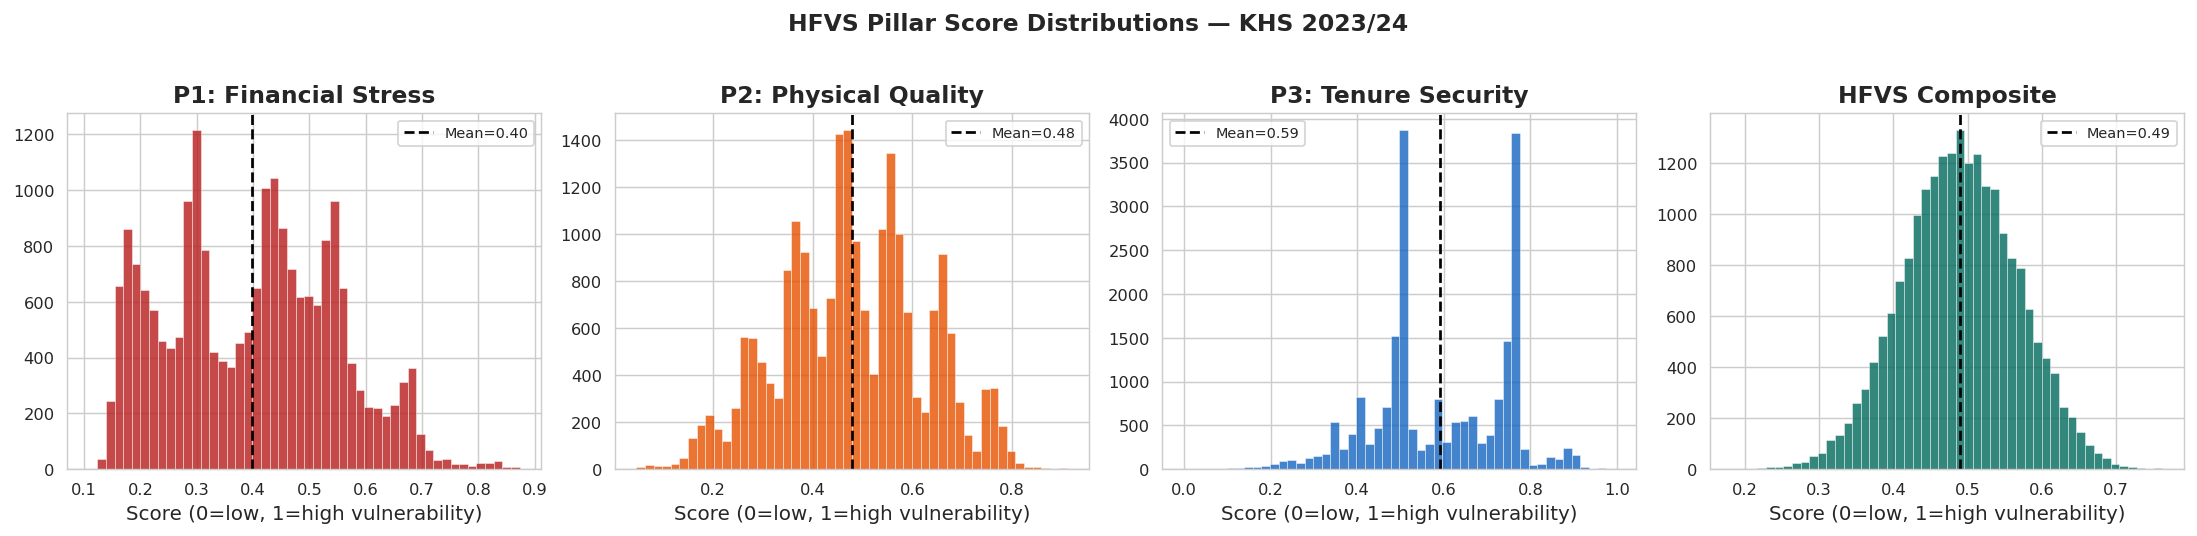

Figure saved.


In [37]:
# ── 6.1  HFVS pillar score distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
pillar_cols = ['hfvs_p1_financial', 'hfvs_p2_physical',
               'hfvs_p3_tenure',    'hfvs_composite']
pillar_labels = ['P1: Financial Stress', 'P2: Physical Quality',
                 'P3: Tenure Security',  'HFVS Composite']
colors_p = [RED, AMBER, BLUE, TEAL]

for ax, col, label, color in zip(axes, pillar_cols, pillar_labels, colors_p):
    ax.hist(model_df[col], bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(model_df[col].mean(), color='black', ls='--', lw=1.5, label=f'Mean={model_df[col].mean():.2f}')
    ax.set_title(label)
    ax.set_xlabel('Score (0=low, 1=high vulnerability)')
    ax.legend(fontsize=8)

plt.suptitle('HFVS Pillar Score Distributions — KHS 2023/24', fontsize=13, fontweight='600', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'hfvs_pillar_distributions.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

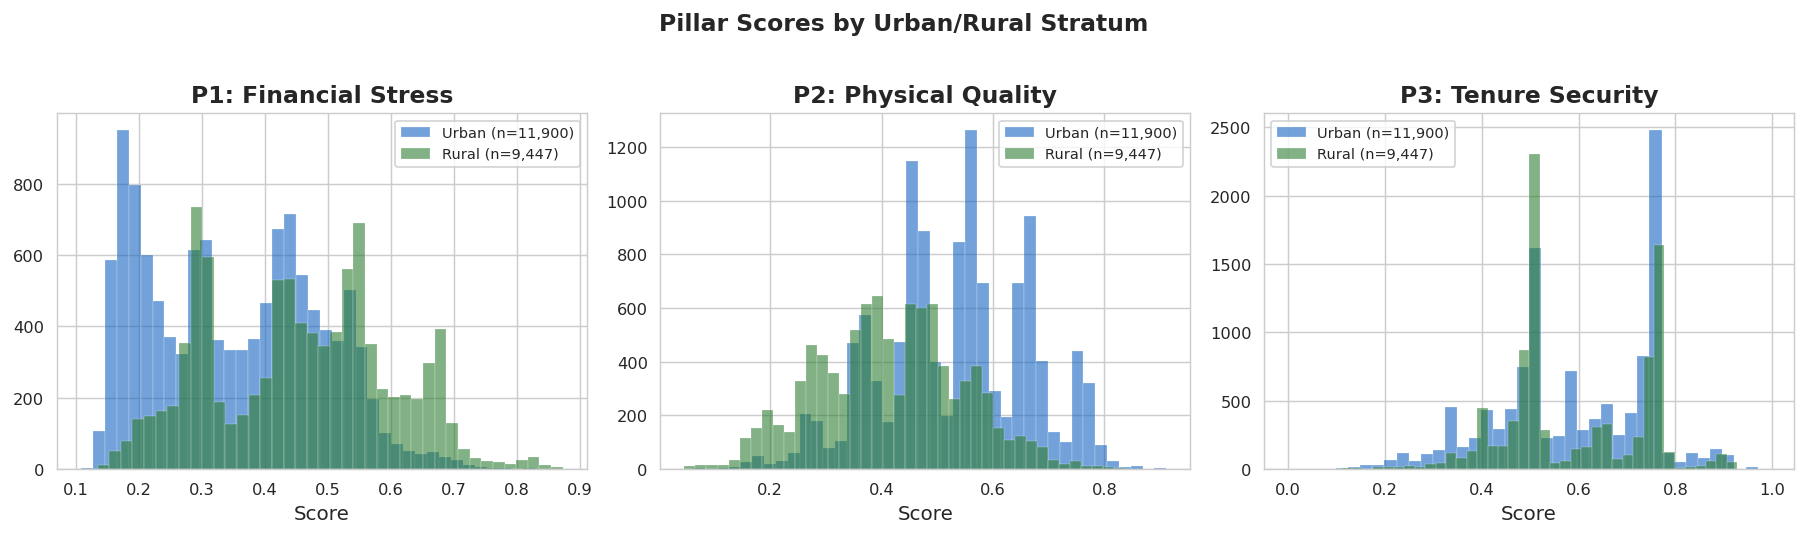

In [38]:
# ── 6.2  Urban vs Rural HFVS comparison ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
urban_labels = {1: 'Urban', 0: 'Rural'}

for ax, col, label in zip(axes, pillar_cols[:3], pillar_labels[:3]):
    for ur_code, ur_label in urban_labels.items():
        subset = model_df[model_df['is_urban'] == ur_code][col]
        ax.hist(subset, bins=40, alpha=0.6,
                label=f'{ur_label} (n={len(subset):,})',
                color=BLUE if ur_code == 1 else GREEN, edgecolor='white', linewidth=0.2)
    ax.set_title(label)
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

plt.suptitle('Pillar Scores by Urban/Rural Stratum', fontsize=13, fontweight='600', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'hfvs_urban_rural.png', bbox_inches='tight')
plt.show()

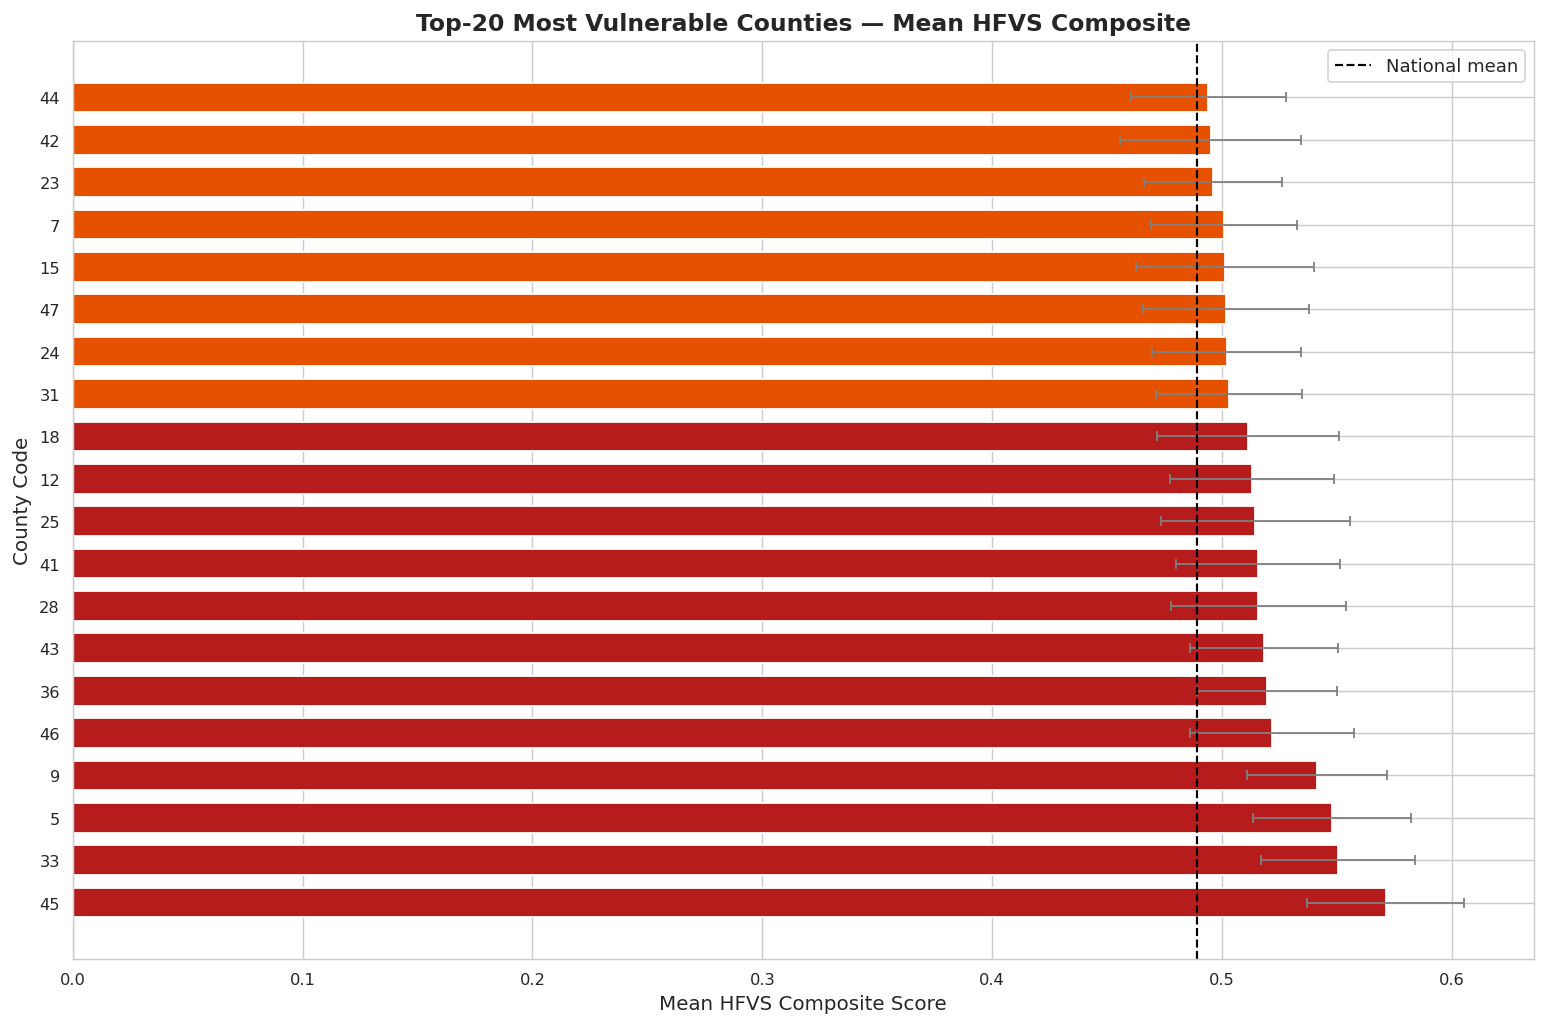

County HFVS table saved.


In [39]:
# ── 6.3  County-level median HFVS heatmap (top 20 counties) ─────────────
county_hfvs = (model_df
               .groupby('county_code')['hfvs_composite']
               .agg(['mean','std','count'])
               .rename(columns={'mean':'HFVS_mean','std':'HFVS_std','count':'n_hh'})
               .sort_values('HFVS_mean', ascending=False))

fig, ax = plt.subplots(figsize=(12, 8))
top20 = county_hfvs.head(20)
colors_bar = [RED if v >= county_hfvs['HFVS_mean'].quantile(0.75) else
              AMBER if v >= county_hfvs['HFVS_mean'].median() else
              GREEN for v in top20['HFVS_mean']]

bars = ax.barh(top20.index.astype(str), top20['HFVS_mean'], color=colors_bar, height=0.7)
ax.errorbar(top20['HFVS_mean'], range(len(top20)),
            xerr=top20['HFVS_std']/2, fmt='none', color='gray', capsize=3, lw=1)
ax.axvline(county_hfvs['HFVS_mean'].mean(), color='black', ls='--', lw=1.2, label='National mean')
ax.set_xlabel('Mean HFVS Composite Score')
ax.set_ylabel('County Code')
ax.set_title('Top-20 Most Vulnerable Counties — Mean HFVS Composite')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'county_hfvs_top20.png', bbox_inches='tight')
plt.show()

county_hfvs.to_csv(TABS / 'county_hfvs_summary.csv')
print('County HFVS table saved.')

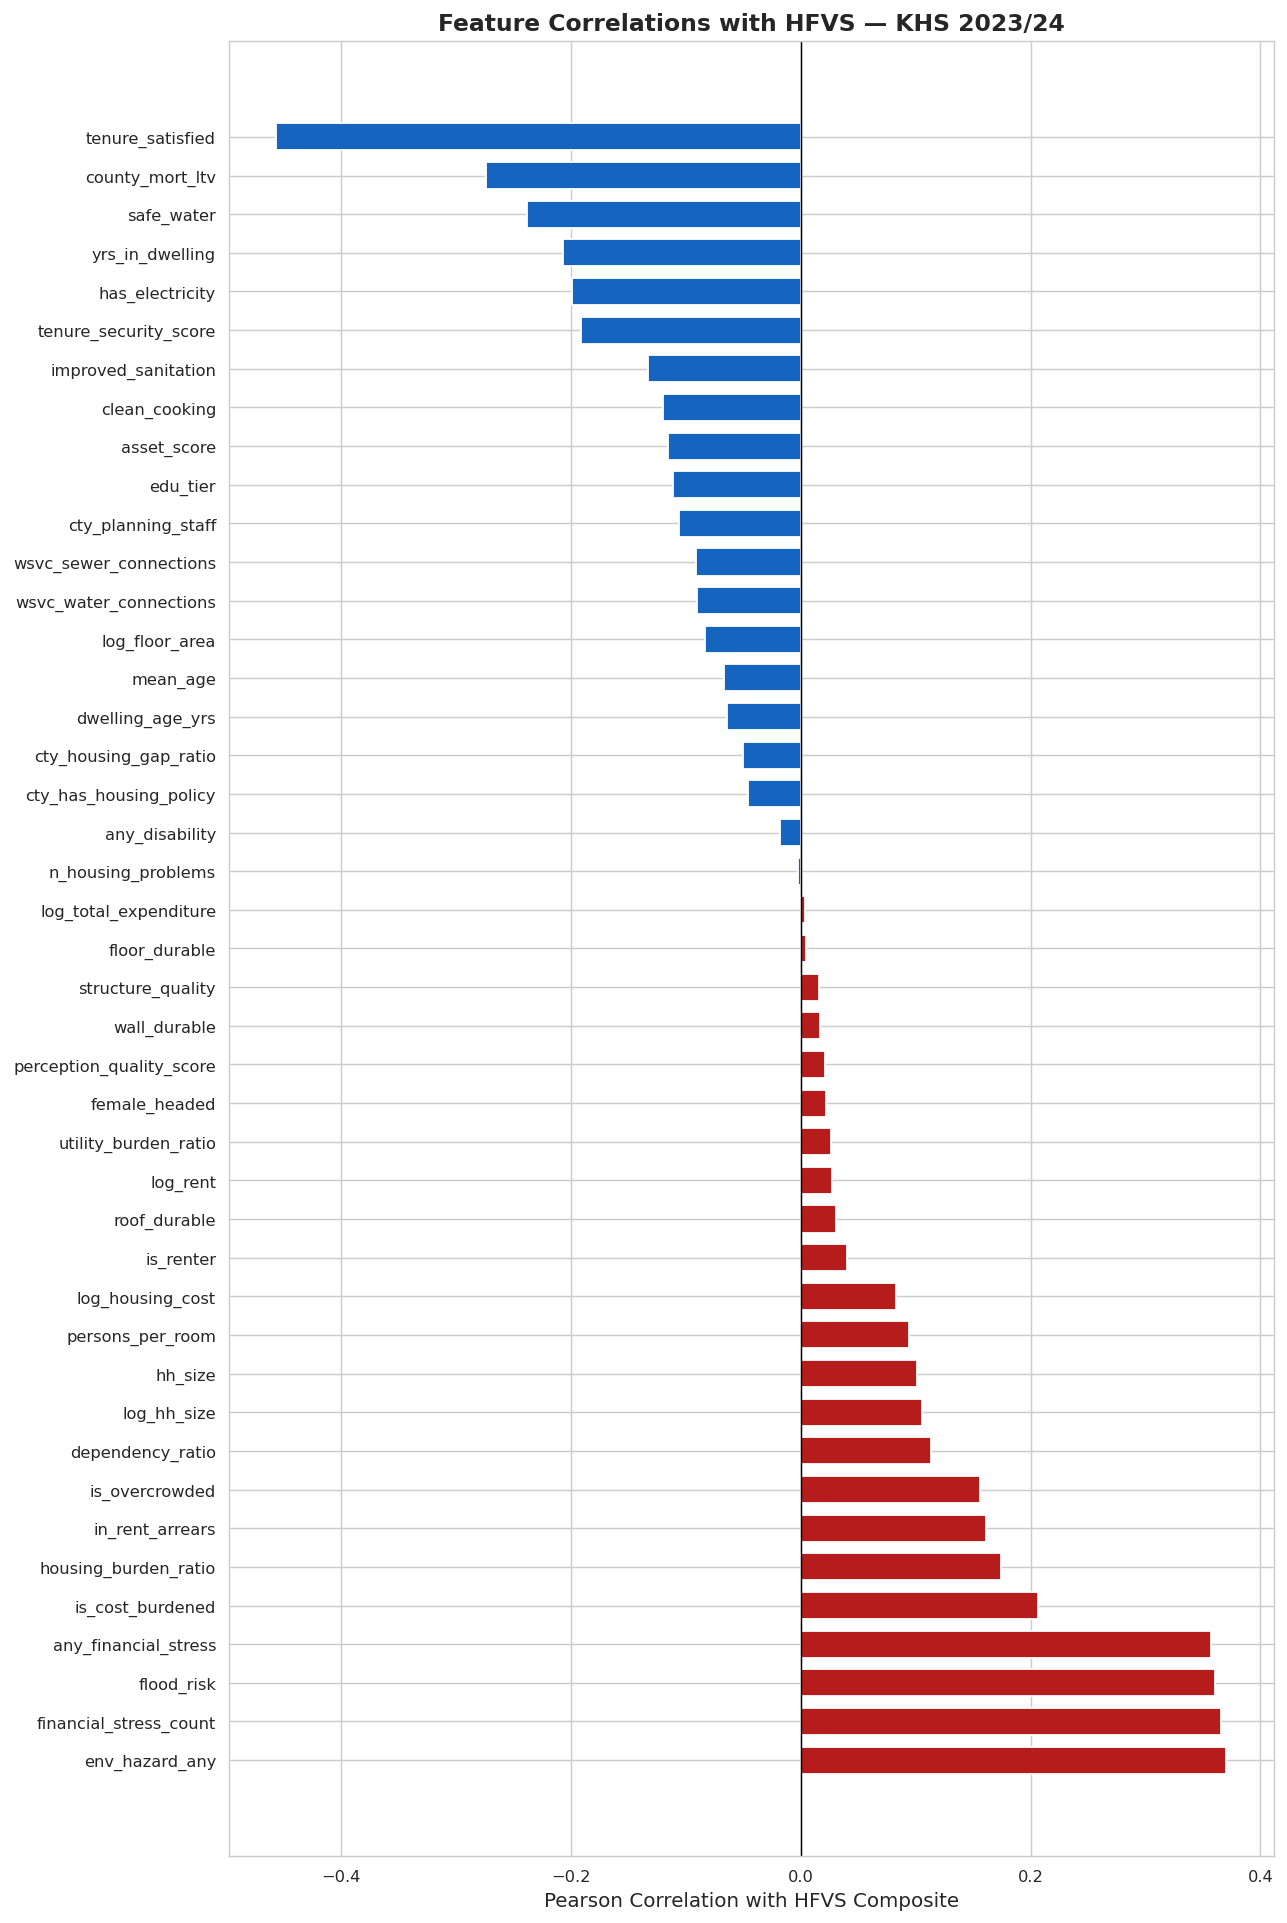

Top 10 positively correlated (vulnerability drivers):
env_hazard_any           0.3705
financial_stress_count   0.3654
flood_risk               0.3602
any_financial_stress     0.3572
is_cost_burdened         0.2066
housing_burden_ratio     0.1744
in_rent_arrears          0.1612
is_overcrowded           0.1559
dependency_ratio         0.1130
log_hh_size              0.1052

Top 10 negatively correlated (protective factors):
edu_tier                -0.1117
asset_score             -0.1156
clean_cooking           -0.1203
improved_sanitation     -0.1328
tenure_security_score   -0.1913
has_electricity         -0.1989
yrs_in_dwelling         -0.2069
safe_water              -0.2382
county_mort_ltv         -0.2743
tenure_satisfied        -0.4566


In [40]:
# ── 6.4  Feature correlation with HFVS composite ─────────────────────────
modelling_features = [
    c for c in model_df.columns
    if FEATURE_MAP.get(c, 'engineered') in ['P1','P2','P3','control','supply']
    and c != 'hfvs_composite'
]

corr_with_hfvs = (
    model_df[modelling_features]
    .corrwith(model_df['hfvs_composite'])
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, len(corr_with_hfvs)*0.3 + 2))
colors_c = [RED if v > 0 else BLUE for v in corr_with_hfvs]
ax.barh(corr_with_hfvs.index, corr_with_hfvs.values, color=colors_c, height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with HFVS Composite')
ax.set_title('Feature Correlations with HFVS — KHS 2023/24')
plt.tight_layout()
plt.savefig(FIGS / 'feature_corr_hfvs.png', bbox_inches='tight')
plt.show()

print('Top 10 positively correlated (vulnerability drivers):')
print(corr_with_hfvs.head(10).to_string())
print('\nTop 10 negatively correlated (protective factors):')
print(corr_with_hfvs.tail(10).to_string())

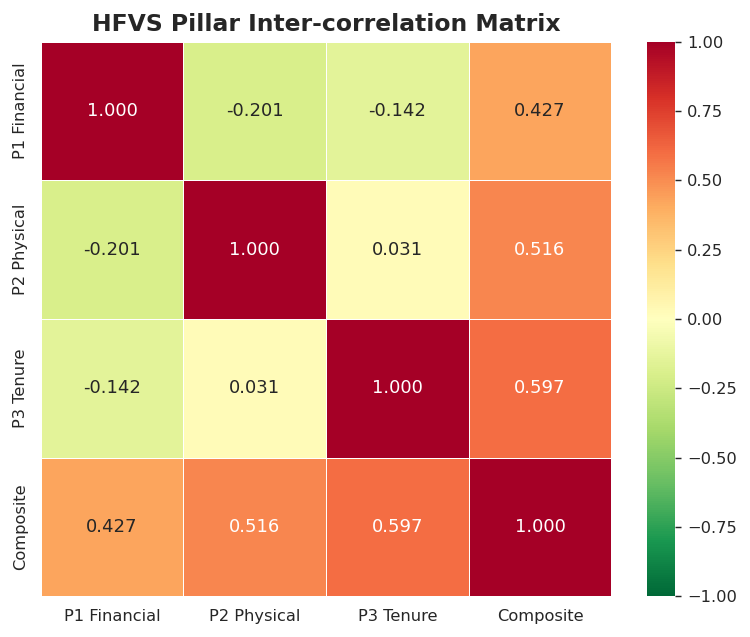


Pillar inter-correlation:
                   hfvs_p1_financial  hfvs_p2_physical  hfvs_p3_tenure  hfvs_composite
hfvs_p1_financial             1.0000           -0.2013         -0.1421          0.4273
hfvs_p2_physical             -0.2013            1.0000          0.0307          0.5164
hfvs_p3_tenure               -0.1421            0.0307          1.0000          0.5965
hfvs_composite                0.4273            0.5164          0.5965          1.0000


In [41]:
# ── 6.5  Pillar inter-correlation matrix ──────────────────────────────────
pillar_corr = model_df[['hfvs_p1_financial','hfvs_p2_physical',
                          'hfvs_p3_tenure','hfvs_composite']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.eye(4, dtype=bool)
sns.heatmap(pillar_corr, annot=True, fmt='.3f', cmap='RdYlGn_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['P1 Financial','P2 Physical','P3 Tenure','Composite'],
            yticklabels=['P1 Financial','P2 Physical','P3 Tenure','Composite'],
            linewidths=0.5)
ax.set_title('HFVS Pillar Inter-correlation Matrix')
plt.tight_layout()
plt.savefig(FIGS / 'pillar_correlation_matrix.png', bbox_inches='tight')
plt.show()

print('\nPillar inter-correlation:')
print(pillar_corr.to_string())

In [42]:
# ── 6.6  Descriptive statistics table ────────────────────────────────────
desc_cols = (
    ['hfvs_composite','hfvs_p1_financial','hfvs_p2_physical','hfvs_p3_tenure',
     'high_vulnerability'] +
    [c for c in modelling_features if c in model_df.columns]
)

desc_stats = model_df[desc_cols].describe(percentiles=[0.1,0.25,0.5,0.75,0.9]).T
desc_stats['missing_pct'] = (model_df[desc_cols].isna().sum() / len(model_df) * 100).values
desc_stats['skewness']    = model_df[desc_cols].apply(lambda x: skew(x.dropna())).values

print(desc_stats.to_string())
desc_stats.to_csv(TABS / 'descriptive_statistics.csv')
print('\nDescriptive statistics saved.')

                              count      mean       std        min      10%      25%       50%       75%       90%       max  missing_pct  skewness
hfvs_composite           21347.0000    0.4895    0.0769     0.1820   0.3907   0.4376    0.4892    0.5418    0.5889    0.7625       0.0000   -0.0444
hfvs_p1_financial        21347.0000    0.3976    0.1496     0.1083   0.1918   0.2810    0.4106    0.5133    0.5871    0.8729       0.0000    0.1875
hfvs_p2_physical         21347.0000    0.4790    0.1444     0.0462   0.2824   0.3747    0.4747    0.5747    0.6681    0.9110       0.0000   -0.0407
hfvs_p3_tenure           21347.0000    0.5919    0.1544     0.0000   0.4017   0.4919    0.5740    0.7503    0.7603    0.9950       0.0000   -0.1752
high_vulnerability       21347.0000    0.2500    0.4330     0.0000   0.0000   0.0000    0.0000    0.5000    1.0000    1.0000       0.0000    1.1546
log_total_expenditure    21347.0000    9.7384    0.9641     2.1972   8.6017   9.0939    9.6928   10.3673   11.05

---
## §7 — Export

Three outputs:
1. `model_ready.parquet` — full feature-engineered dataset for modelling notebook
2. `model_ready.csv` — human-readable version for inspection
3. `feature_map.csv` — feature metadata table for documentation


In [43]:
# ── 7.1  Export parquet (primary) ────────────────────────────────────────
out_parquet = PQ / 'model_ready.parquet'
model_df.to_parquet(out_parquet, index=False)
print(f'Saved: {out_parquet}  ({model_df.shape[0]:,} rows × {model_df.shape[1]} cols)')

# ── 7.2  Export CSV (inspection copy) ────────────────────────────────────
out_csv = TABS / 'model_ready.csv'
model_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

# ── 7.3  Feature map metadata ─────────────────────────────────────────────
feature_meta = pd.DataFrame([
    {'feature': col,
     'pillar': FEATURE_MAP.get(col, 'engineered'),
     'dtype': str(model_df[col].dtype),
     'missing_pct': model_df[col].isna().mean()*100,
     'mean': model_df[col].mean() if model_df[col].dtype != object else None,
     'std':  model_df[col].std()  if model_df[col].dtype != object else None,
    }
    for col in model_df.columns
])

out_meta = TABS / 'feature_map.csv'
feature_meta.to_csv(out_meta, index=False)
print(f'Saved: {out_meta}')
print(feature_meta.to_string())

Saved: /content/drive/MyDrive/KHS_Dissertation/data/parquet/model_ready.parquet  (21,347 rows × 51 cols)
Saved: /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301/model_ready.csv
Saved: /content/drive/MyDrive/KHS_Dissertation/outputs/tables/dsa8301/feature_map.csv
                     feature      pillar    dtype  missing_pct      mean       std
0                county_code          id    Int64       0.0000   24.6134   13.9186
1                   is_urban     stratum     int8       0.0000    0.5575    0.4967
2                   hhweight      weight  float64       0.0000  650.4955  615.4876
3      log_total_expenditure          P1  float64       0.0000    9.7384    0.9641
4           log_housing_cost          P1  float64       0.0000    6.4367    3.1162
5       housing_burden_ratio          P1  float64       0.0000    0.1428    0.1473
6           is_cost_burdened          P1  float64       0.0000    0.1173    0.3217
7       utility_burden_ratio          P1  float64       0.0

In [45]:
print([c for c in model_df.columns if 'key' in c or 'id' in c or 'interview' in c])

[]


In [44]:
# ── 7.4  Final health check ───────────────────────────────────────────────
print('=== FINAL DATASET HEALTH CHECK ===')
print(f'Shape                : {model_df.shape}')
print(f'Total missing cells  : {model_df.isnull().sum().sum()}')
print(f'Duplicate keys       : {model_df["interview__key"].duplicated().sum()}')
print(f'\nTarget distribution  :')
print(model_df['high_vulnerability'].value_counts(normalize=True).mul(100).round(2).to_string())

print(f'\nPillar score summary :')
for col in ['hfvs_p1_financial','hfvs_p2_physical','hfvs_p3_tenure','hfvs_composite']:
    s = model_df[col]
    print(f'  {col:<30}: mean={s.mean():.3f}  std={s.std():.3f}  range=[{s.min():.3f}, {s.max():.3f}]')

print(f'\n✓ Data understanding, cleaning, and engineering complete.')
print(f'   Output: {out_parquet}')

=== FINAL DATASET HEALTH CHECK ===
Shape                : (21347, 51)
Total missing cells  : 0


KeyError: 'interview__key'